# Module 06: OpenCV for Computer Vision & Machine Learning
## Notebook 02: Geometric Transformations, Annotations, and Image Augmentation

Geometric transformations modify the spatial relationships between pixels. They are fundamental in computer vision for coordinate normalization, visual alignment, document deskewing, and constructing training data augmentation pipelines for machine learning models.

---

### Learning Objectives
By the end of this notebook, you will be able to:
1. Render visual annotations and primitives: lines, bounding boxes, circles, and anti-aliased text.
2. Scale images using `cv2.resize()` and select the optimal **interpolation algorithm** (`INTER_NEAREST`, `INTER_LINEAR`, `INTER_CUBIC`, `INTER_AREA`).
3. Apply affine transformations: translation, flipping, and rotation around an arbitrary center with `cv2.getRotationMatrix2D()` and `cv2.warpAffine()`.
4. **Advanced:** Rectify warped perspectives using **4-Point Perspective Transformations (Homography)** with `cv2.getPerspectiveTransform()` and `cv2.warpPerspective()`.
5. **Advanced:** Construct a production-grade **Computer Vision Data Augmentation Pipeline** from scratch with synchronized bounding box transforms.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_dir = "images" if os.path.exists("images") else "../images"
print(f"OpenCV Version: {cv2.__version__}")

OpenCV Version: 5.0.0


### 1. Drawing Primitives & Visual Annotations
Visual inspection and model debugging require overlaying bounding boxes, landmark points, and classification confidences:
- `cv2.line(img, pt1, pt2, color, thickness)`
- `cv2.rectangle(img, pt1, pt2, color, thickness)`: `thickness=-1` fills the rectangle.
- `cv2.circle(img, center, radius, color, thickness)`
- `cv2.putText(img, text, org, fontFace, fontScale, color, thickness, lineType=cv2.LINE_AA)`: `LINE_AA` enables anti-aliasing.

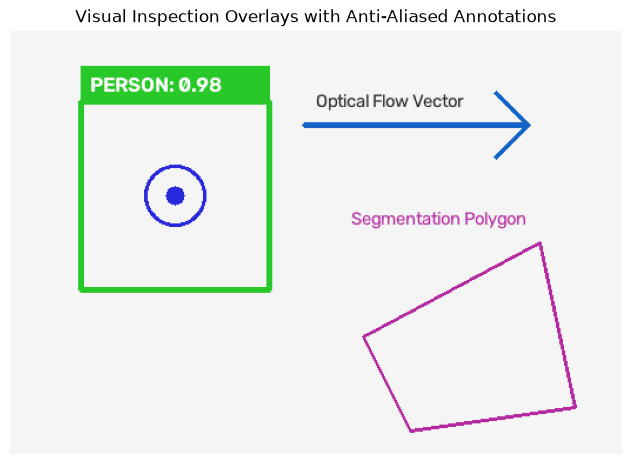

In [2]:
# Create blank canvas
annotated = np.full((360, 520, 3), 245, dtype=np.uint8)

# 1. Bounding box overlay (Green: BGR 40, 200, 40)
cv2.rectangle(annotated, (60, 60), (220, 220), (40, 200, 40), 3)

# 2. Keypoint center marker
cv2.circle(annotated, (140, 140), 8, (220, 40, 40), -1) # Red center
cv2.circle(annotated, (140, 140), 25, (220, 40, 40), 2) # Outer ring

# 3. Directed arrow line
cv2.arrowedLine(annotated, (250, 80), (440, 80), (200, 100, 20), 3, tipLength=0.2)

# 4. Text labels with background banner
cv2.rectangle(annotated, (60, 30), (220, 60), (40, 200, 40), -1)
cv2.putText(annotated, "PERSON: 0.98", (68, 52), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2, cv2.LINE_AA)

cv2.putText(annotated, "Optical Flow Vector", (260, 65), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (40, 40, 40), 1, cv2.LINE_AA)

# 5. Polygon points
poly_pts = np.array([[300, 260], [450, 180], [480, 320], [340, 340]], np.int32)
cv2.polylines(annotated, [poly_pts], isClosed=True, color=(160, 40, 180), thickness=2)
cv2.putText(annotated, "Segmentation Polygon", (290, 165), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (160, 40, 180), 1, cv2.LINE_AA)

plt.figure(figsize=(8, 5.5))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title("Visual Inspection Overlays with Anti-Aliased Annotations")
plt.axis("off")
plt.show()

### 2. Resizing & Interpolation Algorithms
Resizing modifies spatial resolution via `cv2.resize(src, dsize, fx=0, fy=0, interpolation)`.
Choosing the right interpolation method is critical for performance and visual fidelity:
- **`cv2.INTER_NEAREST`:** Nearest-neighbor. Extremely fast ($O(1)$), but produces blocky pixelation. **Mandatory for semantic segmentation masks** where class integers must not be blended!
- **`cv2.INTER_LINEAR`:** Bilinear interpolation ($2 \times 2$ neighborhood). OpenCV's default; excellent speed/quality balance.
- **`cv2.INTER_CUBIC`:** Bicubic interpolation ($4 \times 4$ neighborhood). Superior quality for upscaling images at slight computational cost.
- **`cv2.INTER_AREA`:** Pixel area resampling. Resamples pixel flux; **best practice for downscaling** because it eliminates moiré artifacts.

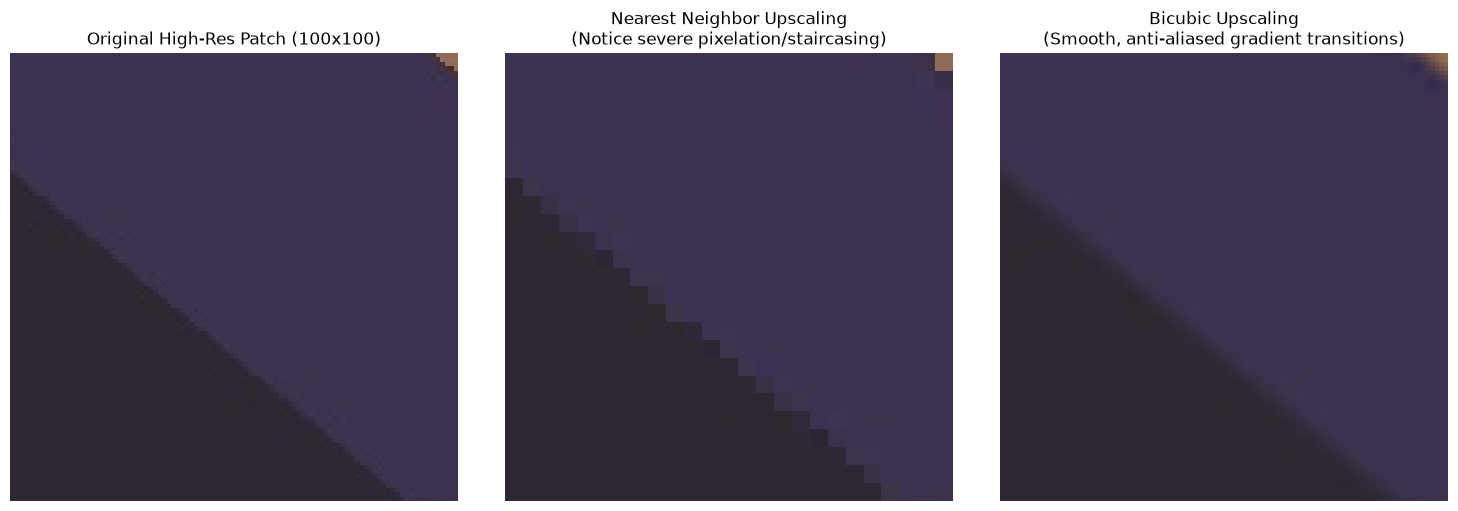

In [3]:
landscape_bgr = cv2.imread(os.path.join(img_dir, "landscape.jpg"))
h_orig, w_orig = landscape_bgr.shape[:2]

# 1. Downscale by 4x using INTER_AREA vs INTER_NEAREST
down_area = cv2.resize(landscape_bgr, (w_orig // 4, h_orig // 4), interpolation=cv2.INTER_AREA)
down_near = cv2.resize(landscape_bgr, (w_orig // 4, h_orig // 4), interpolation=cv2.INTER_NEAREST)

# 2. Upscale back to original resolution using INTER_CUBIC vs INTER_NEAREST
up_cubic = cv2.resize(down_area, (w_orig, h_orig), interpolation=cv2.INTER_CUBIC)
up_near = cv2.resize(down_near, (w_orig, h_orig), interpolation=cv2.INTER_NEAREST)

# Inspect a zoomed patch around the sun/mountain edge
crop_slice = (slice(160, 260), slice(340, 440))
crop_orig = cv2.cvtColor(landscape_bgr[crop_slice], cv2.COLOR_BGR2RGB)
crop_near = cv2.cvtColor(up_near[crop_slice], cv2.COLOR_BGR2RGB)
crop_cubic = cv2.cvtColor(up_cubic[crop_slice], cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(crop_orig)
axes[0].set_title(f"Original High-Res Patch ({crop_orig.shape[0]}x{crop_orig.shape[1]})")
axes[0].axis("off")

axes[1].imshow(crop_near)
axes[1].set_title("Nearest Neighbor Upscaling\n(Notice severe pixelation/staircasing)")
axes[1].axis("off")

axes[2].imshow(crop_cubic)
axes[2].set_title("Bicubic Upscaling\n(Smooth, anti-aliased gradient transitions)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### 3. Affine Transformations: Translation, Rotation & Flipping
An Affine Transformation preserves points, straight lines, and parallelism:
$$\begin{bmatrix} x' \\ y' \end{bmatrix} = \begin{bmatrix} a_{00} & a_{01} \\ a_{10} & a_{11} \end{bmatrix} \begin{bmatrix} x \\ y \end{bmatrix} + \begin{bmatrix} t_x \\ t_y \end{bmatrix} = M \begin{bmatrix} x \\ y \\ 1 \end{bmatrix}$$
where $M$ is a $2 \times 3$ transformation matrix applied via `cv2.warpAffine()`.
- **Flipping:** `cv2.flip(img, flipCode)` (0 = vertical flip around x-axis, 1 = horizontal flip around y-axis, -1 = both axes).
- **Rotation around Center:** `cv2.getRotationMatrix2D(center, angle_deg, scale)` calculates the exact $2 \times 3$ affine matrix.

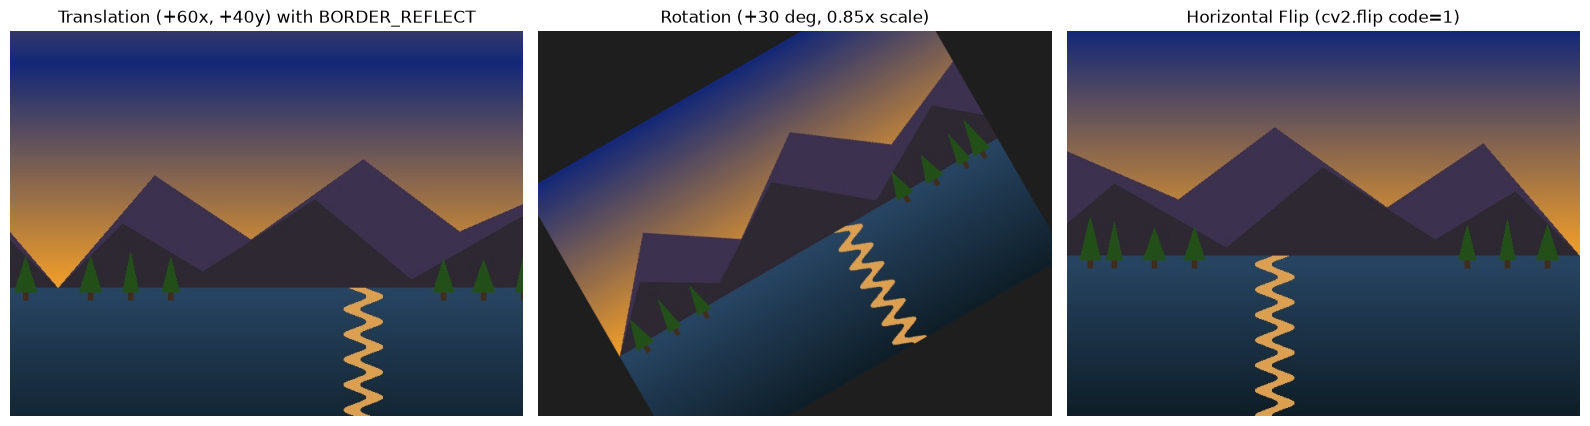

In [4]:
h, w = landscape_bgr.shape[:2]

# 1. 2D Translation: Shift right by 60px, down by 40px
M_trans = np.float32([[1, 0, 60], [0, 1, 40]])
img_translated = cv2.warpAffine(landscape_bgr, M_trans, (w, h), borderMode=cv2.BORDER_REFLECT)

# 2. Arbitrary Rotation: 30 degrees counter-clockwise around image center with 0.85x scale
center = (w // 2, h // 2)
M_rot = cv2.getRotationMatrix2D(center=center, angle=30, scale=0.85)
img_rotated = cv2.warpAffine(landscape_bgr, M_rot, (w, h), borderValue=(30, 30, 30))

# 3. Horizontal Flip
img_flipped = cv2.flip(landscape_bgr, 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(cv2.cvtColor(img_translated, cv2.COLOR_BGR2RGB))
axes[0].set_title("Translation (+60x, +40y) with BORDER_REFLECT")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(img_rotated, cv2.COLOR_BGR2RGB))
axes[1].set_title("Rotation (+30 deg, 0.85x scale)")
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(img_flipped, cv2.COLOR_BGR2RGB))
axes[2].set_title("Horizontal Flip (cv2.flip code=1)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### 4. Complex Application 1: 4-Point Perspective Transformation (Homography)
Unlike affine transformations (which preserve parallelism and require 3 points), a **Perspective Transformation (Homography)** models the projection of a planar surface from a 3D camera viewpoint onto a 2D plane:
$$\begin{bmatrix} x' \\ y' \\ 1 \end{bmatrix} \sim H \begin{bmatrix} x \\ y \\ 1 \end{bmatrix} = \begin{bmatrix} h_{00} & h_{01} & h_{02} \\ h_{10} & h_{11} & h_{12} \\ h_{20} & h_{21} & h_{22} \end{bmatrix} \begin{bmatrix} x \\ y \\ 1 \end{bmatrix}$$
- Requires **4 pairs of corresponding points**.
- `cv2.getPerspectiveTransform(src_pts, dst_pts)` calculates the $3 \times 3$ matrix $H$.
- `cv2.warpPerspective(img, H, (target_w, target_h))` applies the warp.
- *Use Case:* Document scanner apps that rectify photos taken at tilted angles into straight, top-down rectangular pages.

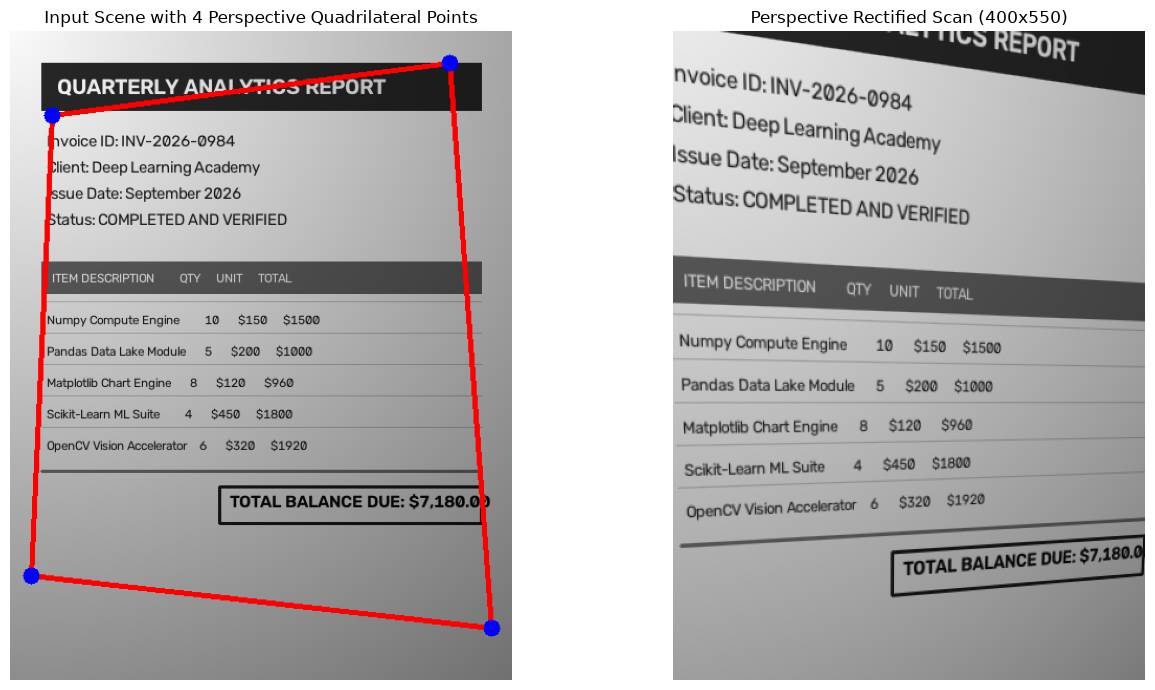

In [5]:
doc_bgr = cv2.imread(os.path.join(img_dir, "document.png"))
h_doc, w_doc = doc_bgr.shape[:2]

# Simulate a tilted camera viewpoint by introducing non-parallel perspective distortion
# Define 4 source corners of the document in the distorted view
src_corners = np.float32([
    [40, 80],      # Top-left
    [w_doc - 60, 30],  # Top-right
    [w_doc - 20, h_doc - 50], # Bottom-right
    [20, h_doc - 100]  # Bottom-left
])

# Define target rectangular canvas dimensions (400x550)
target_w, target_h = 400, 550
dst_corners = np.float32([
    [0, 0],
    [target_w - 1, 0],
    [target_w - 1, target_h - 1],
    [0, target_h - 1]
])

# Compute the 3x3 Homography matrix
H = cv2.getPerspectiveTransform(src_corners, dst_corners)

# Apply perspective warp
warped_doc = cv2.warpPerspective(doc_bgr, H, (target_w, target_h))

# Draw source quadrilateral for visual inspection
preview_src = doc_bgr.copy()
cv2.polylines(preview_src, [src_corners.astype(np.int32)], isClosed=True, color=(0, 0, 255), thickness=3)
for pt in src_corners:
    cv2.circle(preview_src, tuple(pt.astype(np.int32)), 8, (255, 0, 0), -1)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(cv2.cvtColor(preview_src, cv2.COLOR_BGR2RGB))
axes[0].set_title("Input Scene with 4 Perspective Quadrilateral Points")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(warped_doc, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Perspective Rectified Scan ({target_w}x{target_h})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### 5. Complex Application 2: Computer Vision Data Augmentation Pipeline
In machine learning (e.g. YOLO, Faster-RCNN, Vision Transformers), image augmentation prevents overfitting. However, **bounding boxes must be geometrically transformed simultaneously with the image**.
Below, we build a modular `VisionAugmenter` class supporting:
1. Random horizontal flip (with box coordinate flipping).
2. Random affine rotation & scaling around center.
3. Box coordinates transformed via matrix multiplication: $[x', y', 1]^T = M [x, y, 1]^T$.

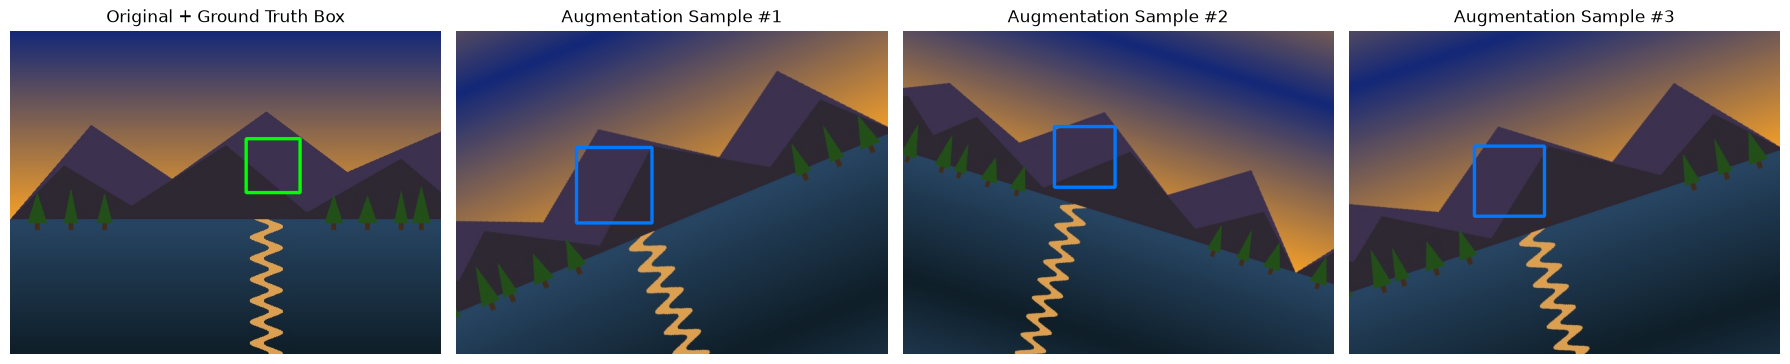

In [6]:
class VisionAugmenter:
    # Production-grade image and bounding-box augmentation engine.
    # Supports simultaneous transformation of visual imagery and ground-truth bounding boxes.
    def __init__(self, rotation_range=(-20, 20), scale_range=(0.85, 1.15), flip_prob=0.5):
        self.rot_min, self.rot_max = rotation_range
        self.s_min, self.s_max = scale_range
        self.flip_prob = flip_prob

    def transform_boxes(self, boxes, M):
        # Transforms bounding boxes [x1, y1, x2, y2] using affine matrix M (2x3).
        transformed_boxes = []
        for box in boxes:
            x1, y1, x2, y2 = box
            # 4 box corner points
            corners = np.array([
                [x1, y1, 1],
                [x2, y1, 1],
                [x2, y2, 1],
                [x1, y2, 1]
            ]).T # (3, 4)
            
            # Map through affine matrix
            new_corners = np.dot(M, corners).T # (4, 2)
            
            # Compute new axis-aligned bounding box enclosing the rotated points
            new_x1 = np.min(new_corners[:, 0])
            new_y1 = np.min(new_corners[:, 1])
            new_x2 = np.max(new_corners[:, 0])
            new_y2 = np.max(new_corners[:, 1])
            transformed_boxes.append([new_x1, new_y1, new_x2, new_y2])
        return transformed_boxes

    def augment(self, image, boxes):
        h, w = image.shape[:2]
        img_out = image.copy()
        boxes_out = [b[:] for b in boxes]

        # 1. Random Horizontal Flip
        if np.random.rand() < self.flip_prob:
            img_out = cv2.flip(img_out, 1)
            boxes_out = [[w - b[2], b[1], w - b[0], b[3]] for b in boxes_out]

        # 2. Random Affine Rotation & Scaling
        angle = np.random.uniform(self.rot_min, self.rot_max)
        scale = np.random.uniform(self.s_min, self.s_max)
        center = (w / 2.0, h / 2.0)
        M = cv2.getRotationMatrix2D(center, angle, scale)

        img_out = cv2.warpAffine(img_out, M, (w, h), borderMode=cv2.BORDER_REFLECT)
        boxes_out = self.transform_boxes(boxes_out, M)

        return img_out, boxes_out

# Instantiate augmenter and test on a synthetic object
np.random.seed(42)
augmenter = VisionAugmenter(rotation_range=(-25, 25), scale_range=(0.85, 1.15), flip_prob=1.0)

# Ground truth object: Sun disc in landscape.jpg
test_img = landscape_bgr.copy()
gt_boxes = [[350, 160, 430, 240]] # [x1, y1, x2, y2]

# Run augmentation 3 times
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

# Original
preview_orig = test_img.copy()
cv2.rectangle(preview_orig, (gt_boxes[0][0], gt_boxes[0][1]), (gt_boxes[0][2], gt_boxes[0][3]), (0, 255, 0), 3)
axes[0].imshow(cv2.cvtColor(preview_orig, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original + Ground Truth Box")
axes[0].axis("off")

for i in range(3):
    aug_img, aug_boxes = augmenter.augment(test_img, gt_boxes)
    # Overlay transformed bounding box
    for bx in aug_boxes:
        cv2.rectangle(aug_img, (int(bx[0]), int(bx[1])), (int(bx[2]), int(bx[3])), (255, 120, 0), 3)
    axes[i + 1].imshow(cv2.cvtColor(aug_img, cv2.COLOR_BGR2RGB))
    axes[i + 1].set_title(f"Augmentation Sample #{i + 1}")
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()